In [6]:
#loading libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

### Load and clean Data

In [9]:
df = pd.read_csv("C:\\Users\\hp\\Downloads\\Book2019(Sheet3).csv")
df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_') #
df = df.drop_duplicates(subset=['CONSTITUENCIES', 'YEAR']) #removing duplicates

### Seperate the data

In [12]:
df_2019 = df[df['YEAR'] == 2019].set_index('CONSTITUENCIES')
df_2024 = df[df['YEAR'] == 2024].set_index('CONSTITUENCIES')

In [14]:
common = df_2019.index.intersection(df_2024.index) ##Align Constituencies Present in Both Years
df_2019 = df_2019.loc[common]
df_2024 = df_2024.loc[common]


### Create Feature Set for the Model

In [17]:
features_2019 = df_2019[['BJP', 'CONGRESS', 'BSP', 'INLD', 'OTHERS']].add_suffix('_2019') #Extracting percentage shares from 2019 and renaming columns
features_2024 = df_2024[['BJP', 'CONGRESS', 'BSP', 'INLD', 'OTHERS']].add_suffix('_2024') #Extracting percentage shares from 2024 and renaming columns
X = pd.concat([features_2019, features_2024], axis=1)#Combines both years’ vote shares into one feature set X.


### Set the target


In [20]:
y = df_2024['WINNER'] #model learns to predict


### Training the model

In [23]:
from sklearn.ensemble import RandomForestClassifier        #input-vote shares in 2019 and 2024
model = RandomForestClassifier(random_state=42)            #output-2024 winner
model.fit(X, y)                                            #The model learns how vote shares relate to the winning party.

RandomForestClassifier(random_state=42)

### Simulate 2029 Vote Shares

In [26]:
X_2029 = X.copy()
for col in X_2029.columns:
    if '_2024' in col:
        X_2029[col] = X_2029[col] * 1.03      ##Simulates a 3% swing (increase) in 2024 vote shares for 2029.


### Predict 2029 Winner per Constituency



In [29]:
y_pred_2029 = model.predict(X_2029) ##Uses the trained model to predict who will win each constituency in 2029.

results = pd.DataFrame({
    'Constituency': common,
    'Predicted_Winner_2029': y_pred_2029
}).reset_index(drop=True)

In [31]:
y_pred_2029


array(['BJP', 'CONGRESS', 'CONGRESS', 'BJP', 'CONGRESS', 'CONGRESS',
       'CONGRESS', 'CONGRESS', 'BJP', 'BJP', 'BJP', 'CONGRESS',
       'CONGRESS', 'CONGRESS', 'CONGRESS', 'OTHERS', 'CONGRESS', 'OTHERS',
       'BJP', 'BJP', 'BJP', 'BJP', 'BJP', 'BJP', 'BJP', 'BJP', 'BJP',
       'OTHERS', 'BJP', 'BJP', 'BJP', 'BJP', 'OTHERS', 'CONGRESS', 'BJP',
       'BJP', 'OTHERS', 'BJP', 'CONGRESS', 'CONGRESS', 'CONGRESS',
       'CONGRESS', 'INLD', 'OTHERS', 'CONGRESS', 'CONGRESS', 'CONGRESS',
       'CONGRESS', 'CONGRESS', 'BJP', 'BJP', 'OTHERS', 'BJP', 'CONGRESS',
       'BJP', 'BJP', 'OTHERS', 'BJP', 'BJP', 'OTHERS', 'CONGRESS',
       'CONGRESS', 'CONGRESS', 'OTHERS', 'CONGRESS', 'CONGRESS',
       'CONGRESS', 'BJP', 'BJP', 'BJP', 'CONGRESS', 'BJP', 'BJP', 'BJP',
       'BJP', 'BJP', 'OTHERS', 'CONGRESS', 'CONGRESS', 'CONGRESS',
       'CONGRESS', 'BJP', 'BJP', 'CONGRESS', 'BJP', 'BJP', 'BJP'],
      dtype=object)

In [33]:
results

,Constituency,Predicted_Winner_2029
0,KALKA,BJP
1,PANCHKULA,CONGRESS
2,NARAINGARH,CONGRESS
3,AMBALA CANTT.,BJP
4,AMBALA CITY,CONGRESS
...,...,...
82,PALWAL,BJP
83,PRITHLA,CONGRESS
84,FARIDABAD NIT,BJP
85,BADKHAL,BJP


### Count Overall Seats per Party

In [36]:
seat_tally = results['Predicted_Winner_2029'].value_counts().reset_index()
seat_tally.columns = ['Party', 'Seats_Won_2029']
seat_tally 


,Party,Seats_Won_2029
0,BJP,41
1,CONGRESS,34
2,OTHERS,11
3,INLD,1


In [38]:
winner_party = seat_tally.iloc[0]
if winner_party['Seats_Won_2029'] >= 46:
    print(f"Predicted overall winner: {winner_party['Party']}")
else:
    print(" Result: No clear majority.")


 Result: No clear majority.


### Summary

In [41]:
# Text Summary
winner_party = seat_tally.iloc[0]
winner_name = winner_party['Party']
winner_seats = winner_party['Seats_Won_2029']

print(" Predicted Seat Tally for Haryana 2029:")
print(seat_tally)
print(f"\n Maximum No of seats won: {winner_name} with {winner_seats} seats")
if winner_seats >= 46:
    print("This party has a clear majority.")
else:
    print("No majority — possible hung assembly or coalition.")


 Predicted Seat Tally for Haryana 2029:
      Party  Seats_Won_2029
0       BJP              41
1  CONGRESS              34
2    OTHERS              11
3      INLD               1

 Maximum No of seats won: BJP with 41 seats
No majority — possible hung assembly or coalition.


### Visualization

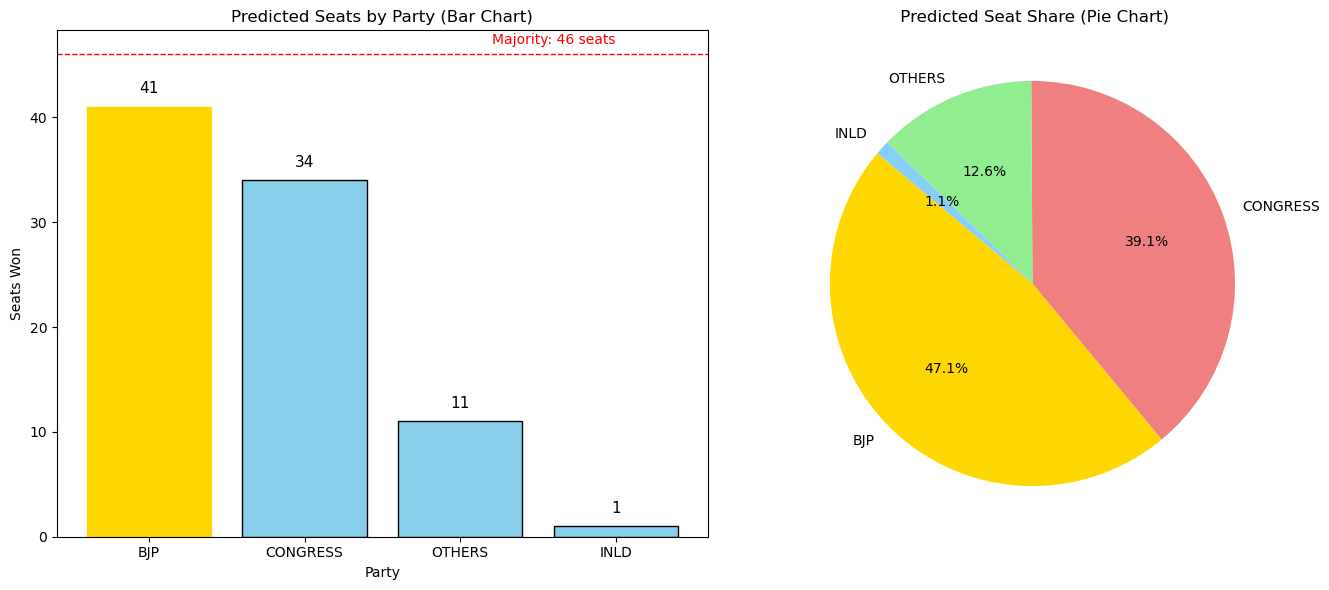

In [44]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Bar Chart
bars = axs[0].bar(seat_tally['Party'], seat_tally['Seats_Won_2029'], color='skyblue', edgecolor='black')
bars[0].set_color('gold')  # highlight top party

for bar in bars:
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2.0, yval + 1, int(yval), ha='center', va='bottom', fontsize=11)

axs[0].axhline(46, color='red', linestyle='--', linewidth=1)
axs[0].text(len(seat_tally)-1, 47, 'Majority: 46 seats', color='red', fontsize=10, ha='right')
axs[0].set_title('Predicted Seats by Party (Bar Chart)')
axs[0].set_ylabel('Seats Won')
axs[0].set_xlabel('Party')
# 2 Pie Chart
axs[1].pie(
    seat_tally['Seats_Won_2029'],
    labels=seat_tally['Party'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['gold', 'lightcoral', 'lightgreen', 'lightskyblue', 'violet']
)
axs[1].set_title(' Predicted Seat Share (Pie Chart)')

plt.tight_layout()
plt.show()

In [46]:
seat_tally.to_csv("overall_haryana_2029_results.csv", index=False)

In [49]:
seat_tally.to_csv('C:/Users/hp/Documents/overall_haryana_2029_results.csv', index=False)

In [51]:
results.to_csv('C:/Users/hp/Documents/constituency_wise_haryana_2029_results.csv', index=False)